In [1]:
import numpy as np
import jax.numpy as jnp
from CartPole import *
from Common import *
from Rollout import *
from RolloutControl import *
from ModelControl import *

In [2]:
initial_state = jnp.array([0.0, 0.0, 0, 0.2])
sigma_l = jnp.array([16, 4, 1, 2])
initial_guess = jnp.array([-1, 1, 10, 0, 1])

In [3]:
A = load_jnp_array("data_JC1/A")
b = load_jnp_array("data_JC1/b")
X_basis = load_jnp_array("data_JC1/X_basis")
alpha = load_jnp_array("data_JC1/alpha")
sigma = load_jnp_array("data_JC1/sigma")

In [4]:
p, pred_loss = repeated_fit_policy(initial_state, sigma_l, 200, A, b, X_basis, alpha, sigma, 3.0)
print(p)
print(pred_loss)

[16.908379   8.369202  44.251392  -1.9155633  6.133481 ]
1.4381121397018433


In [4]:
p = jnp.asarray([16.908379, 8.369202, 44.251392, -1.9155633, 6.133481])

In [5]:
state_array, total_loss = joint_policy_rollout(initial_state, p, sigma_l, A, b, X_basis, alpha, sigma, 3.0)
true_state_array, true_total_loss = true_policy_rollout(initial_state, p, sigma_l, 3.0)
print(total_loss)
print(true_total_loss)

1.4381144
0.1234172


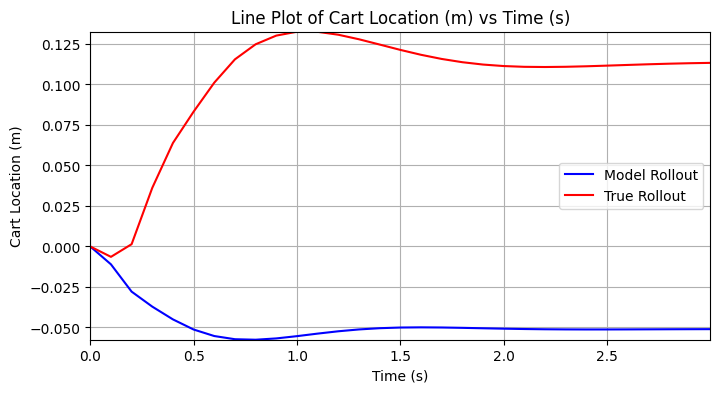

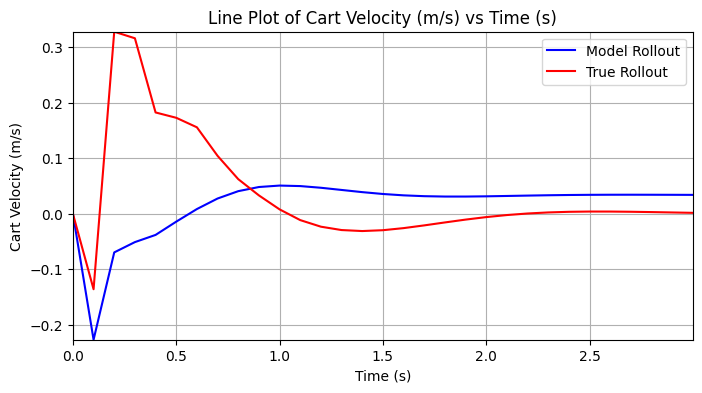

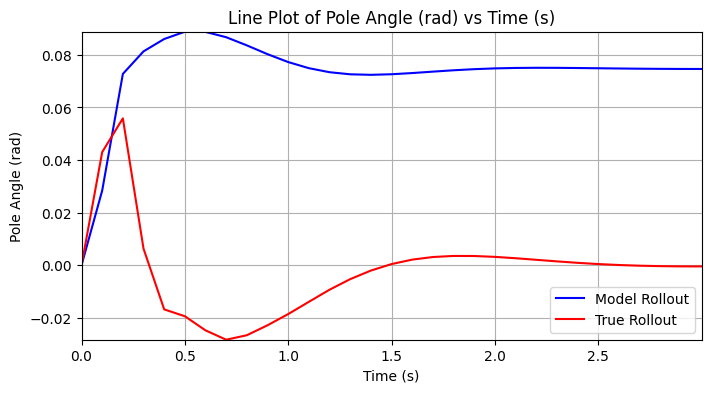

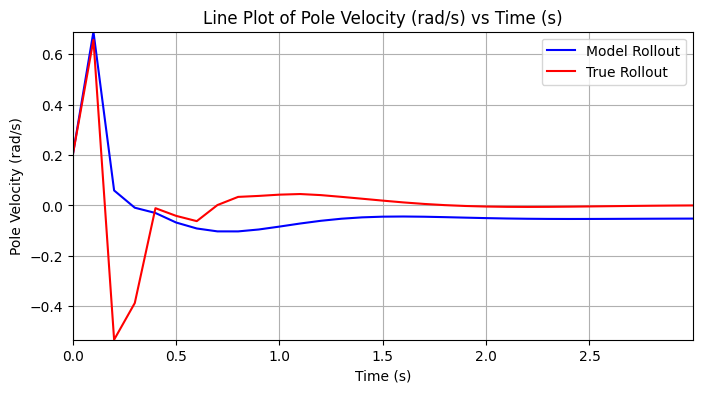

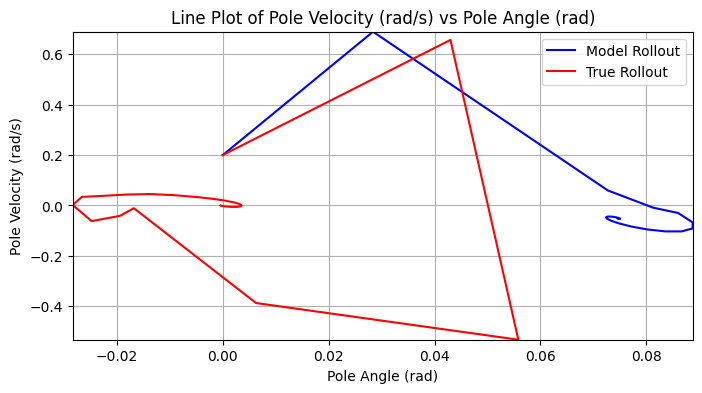

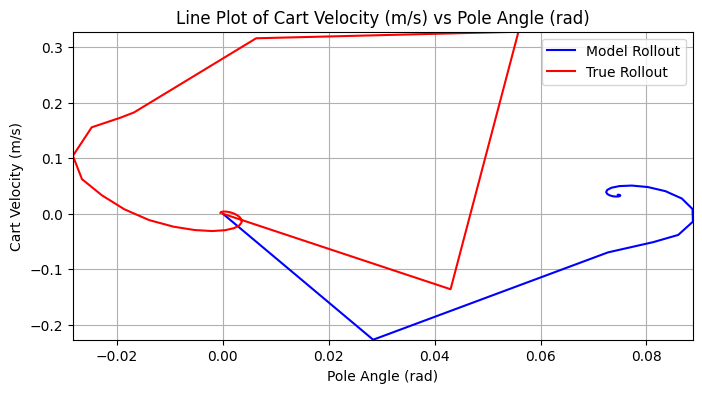

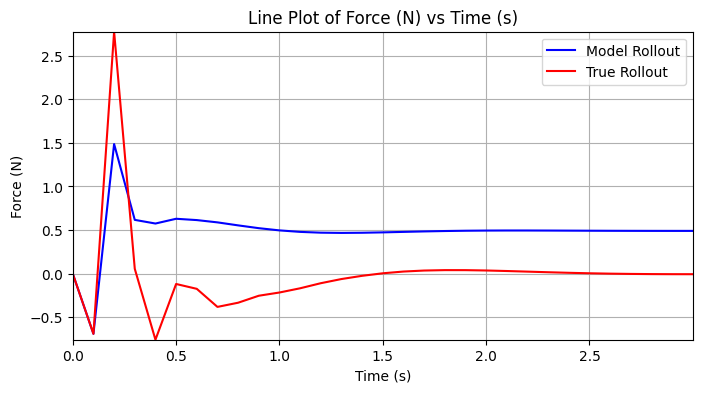

In [6]:
axis_names = ['Cart Location (m)','Cart Velocity (m/s)','Pole Angle (rad)','Pole Velocity (rad/s)', 'Force (N)', 'Time (s)']

plot_model_graph(state_array, true_state_array, -1, 0, axis_names)
plot_model_graph(state_array, true_state_array, -1, 1, axis_names)
plot_model_graph(state_array, true_state_array, -1, 2, axis_names)
plot_model_graph(state_array, true_state_array, -1, 3, axis_names)
plot_model_graph(state_array, true_state_array, 2, 3, axis_names)
plot_model_graph(state_array, true_state_array, 2, 1, axis_names)
plot_model_graph(state_array, true_state_array, -1, -2, axis_names)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=58725ef8-9a26-4e31-9e4c-5d3613b1a28f' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>